In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

In [69]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
ds = xr.open_dataset(r'C:\Users\sebas\Downloads\era5_t2m_2026_daily.nc')

<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


In [4]:
ds

<xarray.Dataset> Size: 113MB
Dimensions:     (valid_time: 251, latitude: 224, longitude: 503)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2026-01-01 ... 2026-09-08
  * latitude    (latitude) float64 2kB 14.0 13.75 13.5 ... -41.25 -41.5 -41.75
  * longitude   (longitude) float64 4kB -162.5 -162.2 -162.0 ... -37.25 -37.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 113MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-14T15:49 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
# Métodos para encontrar datos específicos
ds.latitude.max()
ds.latitude.min()
ds.latitude[0]

<xarray.DataArray 'latitude' ()> Size: 8B
array(14.)
Coordinates:
    number    int64 8B ...
    latitude  float64 8B 14.0
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing

In [9]:
ds.dims

FrozenMappingWarningOnValuesAccess({'valid_time': 251, 'latitude': 224, 'longitude': 503})

In [19]:
# La unidad debe ser del DataArray, no del DataSet
ds['t2m'].attrs
#ds['t2m'].attrs('units')

{'GRIB_paramId': np.int64(167),
 'GRIB_dataType': 'an',
 'GRIB_numberOfPoints': np.int64(112672),
 'GRIB_typeOfLevel': 'surface',
 'GRIB_stepUnits': np.int64(1),
 'GRIB_stepType': 'instant',
 'GRIB_gridType': 'regular_ll',
 'GRIB_uvRelativeToGrid': np.int64(0),
 'GRIB_NV': np.int64(0),
 'GRIB_Nx': np.int64(503),
 'GRIB_Ny': np.int64(224),
 'GRIB_cfName': 'unknown',
 'GRIB_cfVarName': 't2m',
 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid',
 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25),
 'GRIB_iScansNegatively': np.int64(0),
 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25),
 'GRIB_jPointsAreConsecutive': np.int64(0),
 'GRIB_jScansPositively': np.int64(0),
 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(14.0),
 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(-41.75),
 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(-162.5),
 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(-37.0),
 'GRIB_missingValue': np.float64(3.4028234663852886e+38),
 'G

In [ ]:
# Para ver la distribución del tiempo del DataSet
ds['valid_time']

<xarray.DataArray 'valid_time' (valid_time: 251)> Size: 2kB
array(['2026-01-01T00:00:00.000000000', '2026-01-02T00:00:00.000000000',
       '2026-01-03T00:00:00.000000000', ..., '2026-09-06T00:00:00.000000000',
       '2026-09-07T00:00:00.000000000', '2026-09-08T00:00:00.000000000'],
      shape=(251,), dtype='datetime64[ns]')
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2026-01-01 ... 2026-09-08
    number      int64 8B ...
Attributes:
    long_name:      time
    standard_name:  time
    time_shift:     0 days 00:00:00

In [47]:
# Seleccionar un punto 0, 85W
serie_punto = ds['t2m'].sel(latitude=0, longitude=-85)
t2m_c = ds['t2m']-273

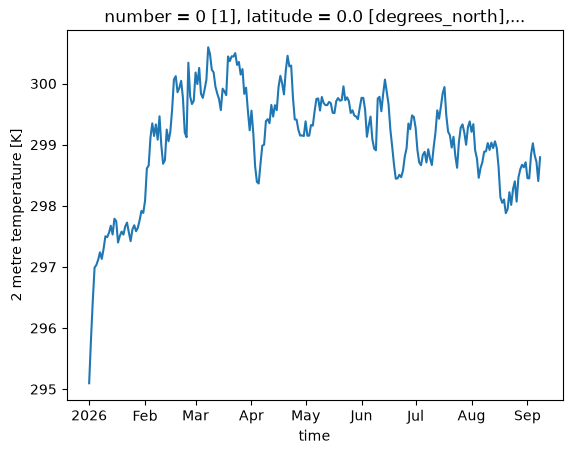

In [ ]:
# Plot de los datos de la variable definida
serie_punto.plot(x='valid_time')

# La data de la variable es un array, entonces se puede realizar operaciones dentro o fuera de la definición del plot
(serie_punto-273).plot(x='valid_time') # Para presentar el valor como celcius

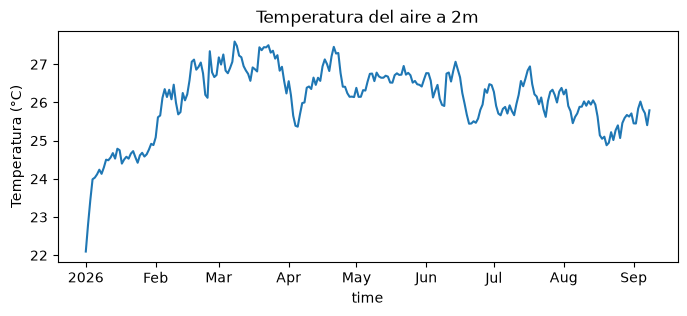

In [49]:
# El problema con el gráfico a Celcius de la figura anterior es que el eje y mostraba la data como temperatura kelvin (K). Para corregir eso, se plotea todos los datos

fig, ax = plt.subplots(figsize=(8,3))

(serie_punto-273).plot(x='valid_time', ax=ax)
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Temperatura del aire a 2m')
plt.show()

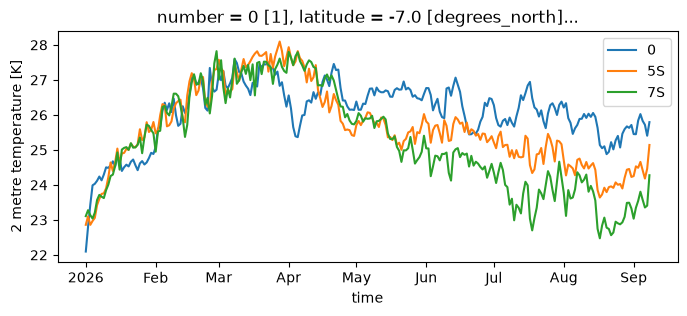

In [62]:
# También se puede graficar directamente la data
fig, ax = plt.subplots(figsize=(8,3))

t2m_c.sel(latitude=0, longitude=-85, method='nearest').plot(x='valid_time', ax=ax, label='0')
t2m_c.sel(latitude=-5, longitude=-85, method='nearest').plot(x='valid_time', ax=ax, label='5S')
t2m_c.sel(latitude=-7, longitude=-85, method='nearest').plot(x='valid_time', ax=ax, label='7S')

ax.legend()
plt.show()

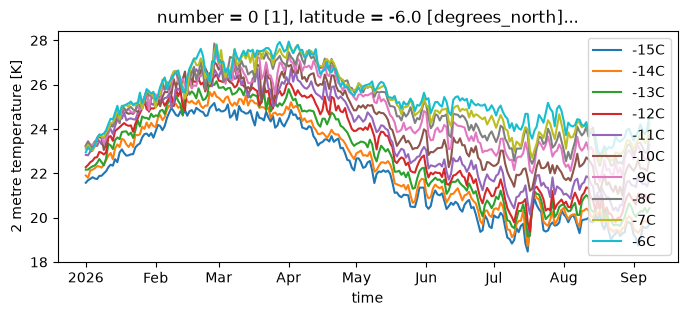

In [65]:
# Si se trabaja con más data de otras localidades, se puede hacer una iteración
fig, ax = plt.subplots(figsize=(8,3))

for i in np.arange(-15,-5):
    t2m_c.sel(latitude=i, longitude=-85, method='nearest').plot(x='valid_time', ax=ax, label=str(i)+'C')

ax.legend()
plt.show()

In [52]:
# Seleccionar una región
t2m_region = t2m_c.sel(latitude=slice(0,-10), longitude= slice(-90, -80))

In [53]:
t2m_region.shape

(251, 41, 41)

In [56]:
# Para hacer operaciones se debe especificar la dimensión. Se pueden agregar más dimensiones como lista
t2m_region.mean(dim=['valid_time'])

<xarray.DataArray 't2m' (latitude: 41, longitude: 41)> Size: 7kB
array([[26.19967 , 26.159115, 26.214905, ..., 26.174076, 26.346085,
        26.36993 ],
       [26.111877, 26.108139, 26.145813, ..., 26.575888, 26.7683  ,
        26.179253],
       [25.982775, 26.071606, 26.07937 , ..., 27.037027, 27.014957,
        26.410545],
       ...,
       [24.478062, 24.473305, 24.47196 , ..., 23.602507, 23.47009 ,
        23.254951],
       [24.389025, 24.388504, 24.378887, ..., 23.555412, 23.45169 ,
        23.251923],
       [24.290764, 24.293467, 24.271624, ..., 23.581308, 23.434654,
        23.234617]], shape=(41, 41), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 328B 0.0 -0.25 -0.5 -0.75 ... -9.5 -9.75 -10.0
  * longitude  (longitude) float64 328B -90.0 -89.75 -89.5 ... -80.25 -80.0
    number     int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      112672
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

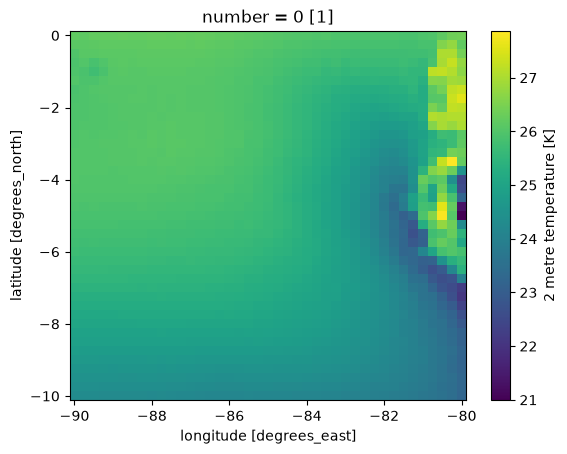

In [58]:
t2m_region.mean(dim=['valid_time']).plot()

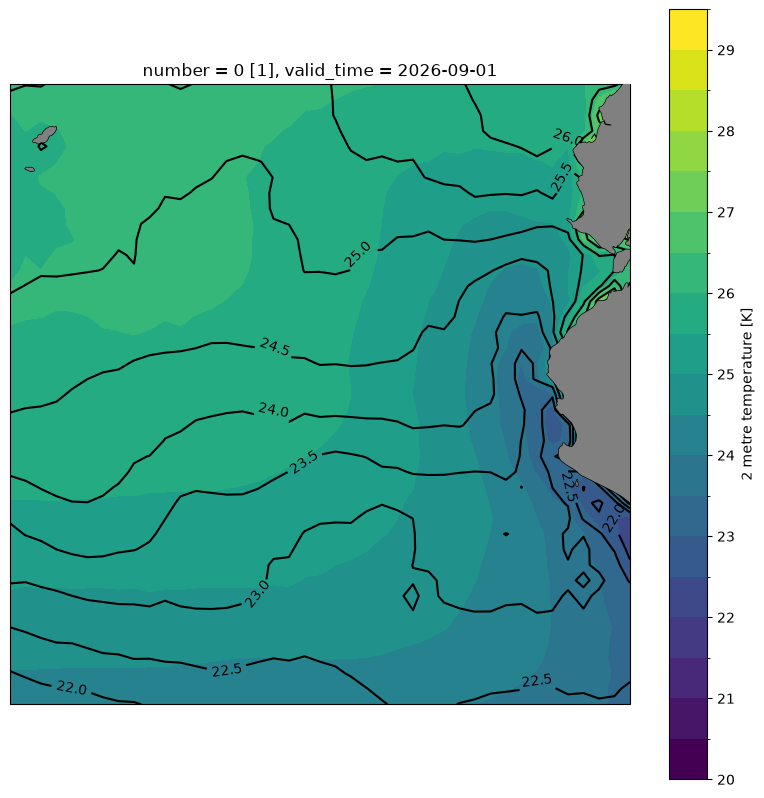

In [75]:
fig, ax = plt.subplots(figsize=(10,10), subplot_kw={'projection':ccrs.PlateCarree()})

# Contorno relleno: es el promedio
t2m_region.mean(dim=['valid_time']).plot.contourf(ax=ax, transform=ccrs.PlateCarree(), levels=np.arange(20,30,0.5))

c = t2m_region.sel(valid_time='2026-9-1').plot.contour(ax=ax, transform=ccrs.PlateCarree(),
                                                    levels=np.arange(20,30,0.5), colors='k')

ax.clabel(c)
ax.add_feature(cfeature.LAND, facecolor='gray', zorder=10) #zorder, en qué orden se va a mostrar el elemento. 
ax.coastlines()